In [ ]:
### pip install pystan
### conda install -c conda-forge fbprophet
!pip install prophet
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/airline_passengers.csv')

In [ ]:
df.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [ ]:
df.tail()

,Month,Thousands of Passengers
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


<Axes: >

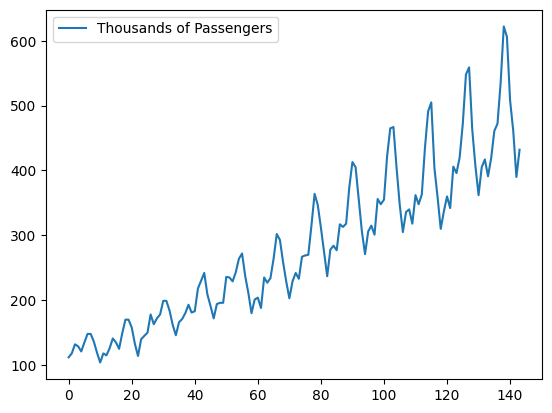

In [ ]:
df.plot()

In [ ]:
df.columns = ['ds','y']
df.head()

,ds,y
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [ ]:
df.drop(144,axis=0,inplace=True)

In [ ]:
df.tail()

,ds,y
139,1960-08,606.0
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0


In [ ]:
df['ds'] = pd.to_datetime(df['ds'])

In [ ]:
df.head()

,ds,y
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [ ]:
df.tail()

,ds,y
139,1960-08-01,606.0
140,1960-09-01,508.0
141,1960-10-01,461.0
142,1960-11-01,390.0
143,1960-12-01,432.0


In [ ]:
dir(Prophet)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_load_stan_backend',
 '_logistic_uncertainty',
 '_make_historical_mat_time',
 '_make_trend_shift_matrix',
 '_sample_uncertainty',
 'add_country_holidays',
 'add_group_component',
 'add_regressor',
 'add_seasonality',
 'calculate_initial_params',
 'construct_holiday_dataframe',
 'fit',
 'flat_growth_init',
 'flat_trend',
 'fourier_series',
 'initialize_scales',
 'linear_growth_init',
 'logistic_growth_init',
 'make_all_seasonality_features',
 'make_future_dataframe',
 'make_holiday_features',
 'make_seasonality_features',
 'parse_seasonality_args',
 'percentile',
 'piecewise_linear',
 

In [ ]:
# Initialize the Model
model=Prophet()

In [ ]:
df.columns

Index(['ds', 'y'], dtype='object')

In [ ]:
df.dropna(axis=0,inplace=True)
df.head()

,ds,y
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [ ]:
model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [ ]:
df.tail()

,ds,y
139,1960-08-01,606.0
140,1960-09-01,508.0
141,1960-10-01,461.0
142,1960-11-01,390.0
143,1960-12-01,432.0


In [ ]:
### Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)

In [ ]:
future_dates.tail()

,ds
504,1961-11-27
505,1961-11-28
506,1961-11-29
507,1961-11-30
508,1961-12-01


In [ ]:
prediction=model.predict(future_dates)

In [ ]:
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,107.406531,57.697195,115.630776,107.406531,107.406531,-21.387397,-21.387397,-21.387397,-21.387397,-21.387397,-21.387397,0.0,0.0,0.0,86.019134
1,1949-02-01,109.550753,50.805947,108.292932,109.550753,109.550753,-30.055287,-30.055287,-30.055287,-30.055287,-30.055287,-30.055287,0.0,0.0,0.0,79.495466
2,1949-03-01,111.487469,83.427674,139.838967,111.487469,111.487469,-0.461745,-0.461745,-0.461745,-0.461745,-0.461745,-0.461745,0.0,0.0,0.0,111.025724
3,1949-04-01,113.631691,82.691639,138.814565,113.631691,113.631691,-4.912527,-4.912527,-4.912527,-4.912527,-4.912527,-4.912527,0.0,0.0,0.0,108.719164
4,1949-05-01,115.706744,83.207885,140.336024,115.706744,115.706744,-3.611280,-3.611280,-3.611280,-3.611280,-3.611280,-3.611280,0.0,0.0,0.0,112.095464


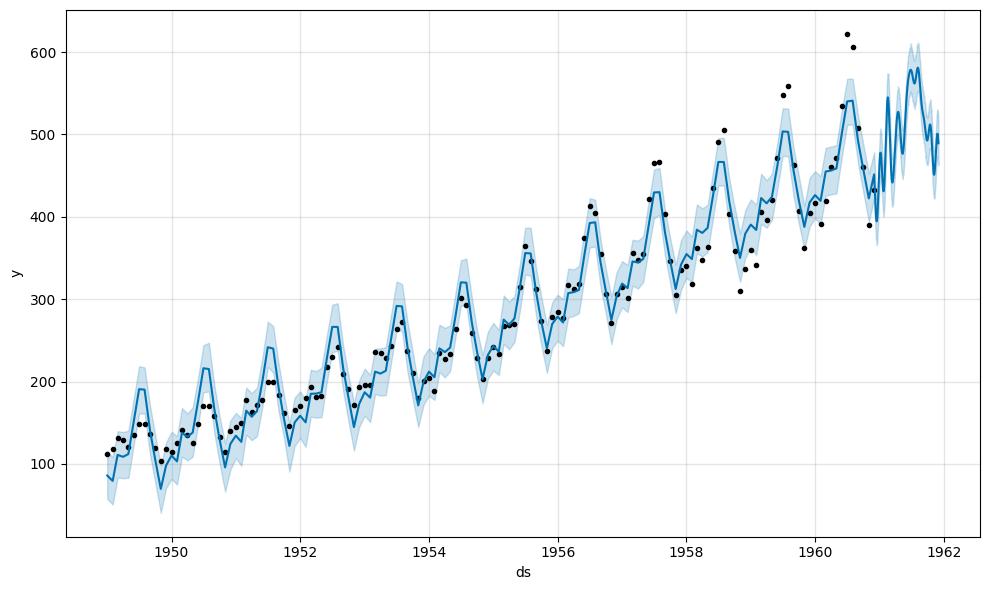

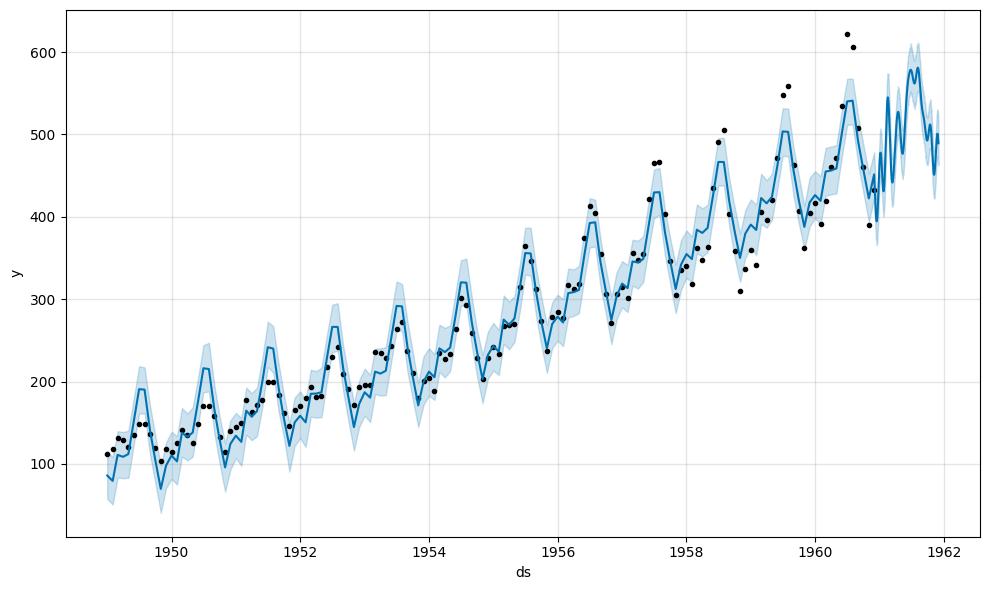

In [ ]:
### plot the predicted projection
model.plot(prediction)

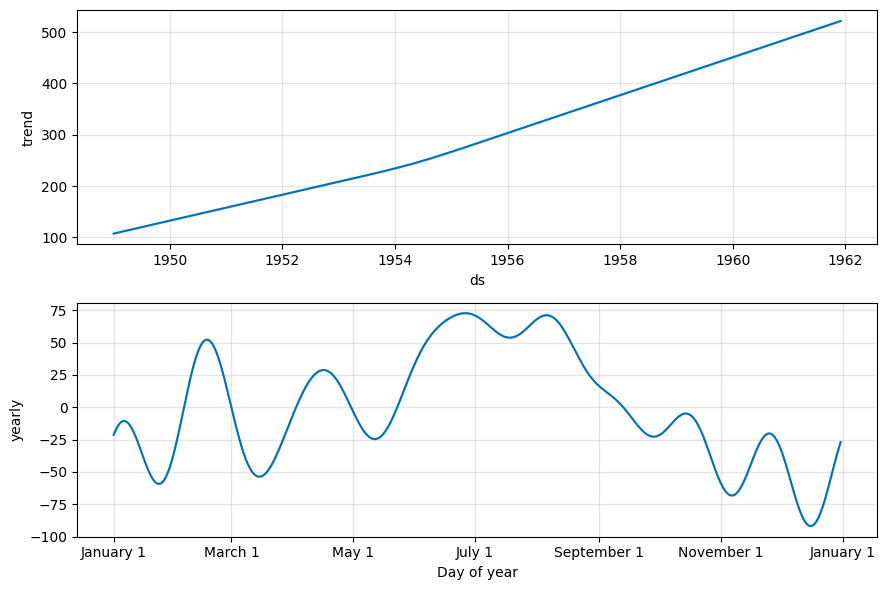

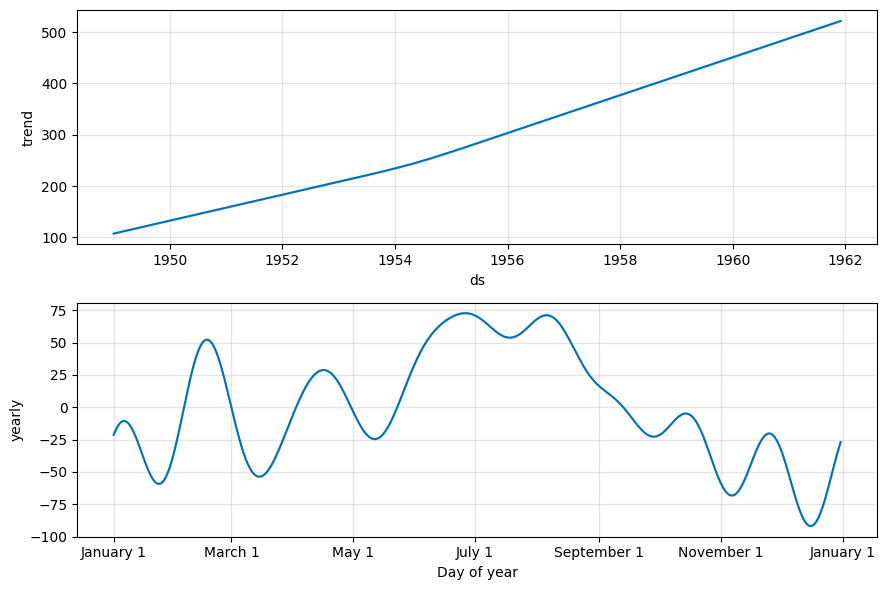

In [ ]:
#### Visualize Each Components[Trends,yearly]
model.plot_components(prediction)

In [ ]:
#Time Series Analysis

1960-1962
#Cross Validation
1960-61 #Train dataset
1961-62 #Test dataset
1962-63 #Validation

1899

In [ ]:
df.head()

,ds,y
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [ ]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')
df_cv.head()

INFO:prophet:Making 19 forecasts with cutoffs between 1951-01-18 00:00:00 and 1959-12-02 00:00:00


  0%|          | 0/19 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1951-02-01,158.547167,158.298740,158.805972,150.0,1951-01-18
1,1951-03-01,171.930526,171.145716,172.677379,178.0,1951-01-18
2,1951-04-01,160.294098,158.729913,161.765220,163.0,1951-01-18
3,1951-05-01,146.088907,143.720531,148.311435,172.0,1951-01-18
4,1951-06-01,181.775447,178.508592,184.917033,178.0,1951-01-18


In [ ]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,40 days,1089.756319,33.011457,25.888132,0.078584,0.073831,0.079624,0.227273
1,42 days,1015.069514,31.860156,25.207098,0.076726,0.073831,0.077409,0.181818
2,46 days,909.811604,30.163083,24.621984,0.078579,0.078887,0.078319,0.136364
3,47 days,1044.412302,32.317368,26.737303,0.081350,0.085408,0.081498,0.136364
4,48 days,1034.021370,32.156203,26.194391,0.079480,0.085408,0.079693,0.181818


https://docs.google.com/document/d/1kflJtIrV23DaGH2bF7fLJyTYq-uqsu2D7SFrRpdQ3bk/edit?usp=sharing

In [ ]:
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,40 days,1089.756319,33.011457,25.888132,0.078584,0.073831,0.079624,0.227273
1,42 days,1015.069514,31.860156,25.207098,0.076726,0.073831,0.077409,0.181818
2,46 days,909.811604,30.163083,24.621984,0.078579,0.078887,0.078319,0.136364
3,47 days,1044.412302,32.317368,26.737303,0.081350,0.085408,0.081498,0.136364
4,48 days,1034.021370,32.156203,26.194391,0.079480,0.085408,0.079693,0.181818


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


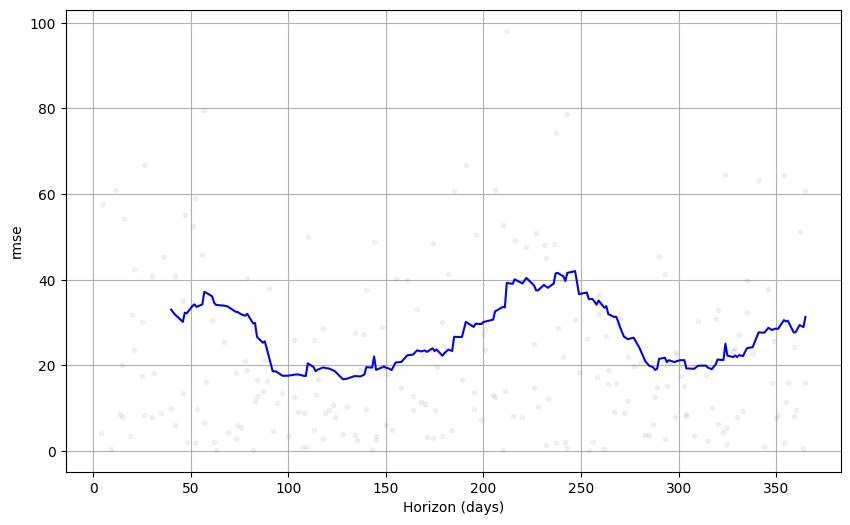

In [ ]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

FINAL OUTCOME OF THE NOTEBOOK

This notebook successfully:

✅ Loads airline passenger time series data

✅ Cleans and prepares dataset

✅ Trains Prophet forecasting model

✅ Predicts future passenger counts for 365 days

✅ Visualizes trend and seasonality

✅ Evaluates model accuracy using cross-validation and RMSE